<center><a target="_blank" href="https://academy.constructor.org/"><img src=https://lh3.googleusercontent.com/d/1fypIr9T-7ntcsVQFmC2_iMPcsm7h8jXg width="500" style="background:none; border:none; box-shadow:none;" /></a> </center>
<hr />

# <h1 align="center"> Day1: Descriptive Statistics. Exercise Session 2: Law of Large Numbers and Central Limit Theorem </h1> </center>

<p style="margin-bottom:1cm;"></p>

_____

<center>Constructor Nexademy, 2026</center>



# Verify the Law of Large Numbers

The Law of Large Numbers states that:

“The average of the results obtained from a large number of trials should be close to the expected value and will tend to become closer to the expected value as more trials are performed” (Dekking, Michel. 2005. A Modern Introduction to Probability and Statistics)

We can get a feeling about what it means by applying it to a dataset. Let’s read the Online Retail csv file and examine it:



In [2]:
# reading data from csv
import pandas as pd
import matplotlib.pyplot as plt

# OnlineRetail.csv
data_file = 'https://drive.google.com/uc?export=download&id=1esCoJ06JWPeUyYBqtvMYioAjREQPqfit'
df = pd.read_csv(data_file, encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

We have 8 columns showing:

- InvoiceNo: invoice number
- StockCode: code unique to the specific item
- Description: description of the item
- Quantity: quantity of items pruchased
- InvoiceDate: date of purchase
- UnitPrice: unit price of the item pruchase
- CustomerID: Unique ID attached to a specific customer
- Country: Country of Purchase

For example, let’s apply the law of Large Number to this dataset. It could translate to:

“The average of the daily retail store income from a large number of days should be close to the expected value (expected daily income) and will tend to become closer to the expected value as more days are taken into account.”

So now let’s investigate if this is true!

## Compute daily sales

The first step is to build a daily sales dataframe from the raw data we loaded.

We start by converting the InvoiceDate column to a `datetime` column:

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format="%m/%d/%Y %H:%M").dt.date
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,12680.0,France


We only want the day, month, and year from the invoice date, but the original data also contained values for hours and minutes. Conveniently, the date is reformatted as YYYY-MM-DD by default.

Finally, we can compute the total daily sales of the shop:

In [ ]:
df['revenue'] = df['UnitPrice'] * df['Quantity']

In [ ]:
df_grouped = df.drop(['CustomerID', 'UnitPrice', 'InvoiceNo', 'StockCode', 'Description', 'Country'], axis=1).groupby(['InvoiceDate']).sum()
df_grouped

,Quantity,revenue
InvoiceDate,,
2010-12-01,26814,58635.56
2010-12-02,21023,46207.28
2010-12-03,14830,45620.46
2010-12-05,16395,31383.95
2010-12-06,21419,53860.18
...,...,...
2011-12-05,44119,57751.32
2011-12-06,29026,54228.37
2011-12-07,39612,75076.22


Let's plot a histogram of these daily sales:

<IPython.core.display.Javascript object>


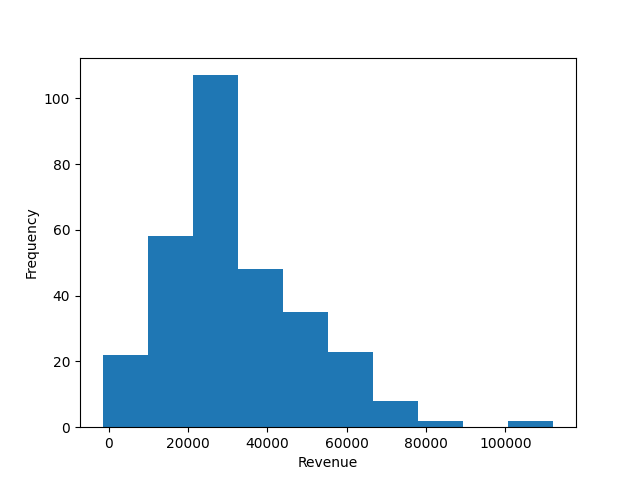

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.hist(df_grouped["revenue"])
plt.ylabel('Frequency')
plt.xlabel('Revenue')
plt.show()

## Your Turn: Verify the law of large numbers on the daily sales dataframe

Create a list named `avg_daily_revenues` that contains the daily average revenue, taking into account 2, 3, 4, … 300 days, sampled randomly.

**Hint:** Checkout the train-test split exercise (STI_D1_EX1_Train_Test_Split_on_the_Retail_Dataset) for a demonstration on how to sample randomly from a dataframe.

Make a line plot with help of the list and see what happens, when progressing in number of sampled days.

In [5]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

daily_revenues = df.groupby('InvoiceDate')['Revenue'].sum()

daily_revenues_df = daily_revenues.reset_index()
print(daily_revenues_df.head())

       InvoiceDate  Revenue
0  1/10/2011 10:04     0.00
1  1/10/2011 10:07   -15.00
2  1/10/2011 10:08     0.00
3  1/10/2011 10:32   326.78
4  1/10/2011 10:35   512.59


In [6]:
avg_daily_revenues = []
days_range = range(2, 301)

for n in days_range:
    sample_days = daily_revenues_df['Revenue'].sample(n)
    sample_avg = sample_days.mean()
    avg_daily_revenues.append(sample_avg)

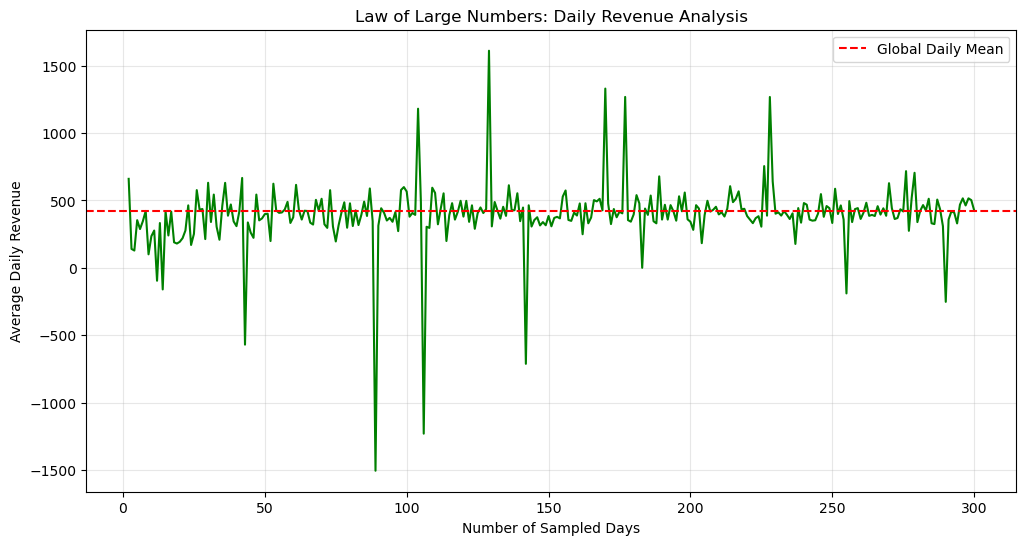

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(days_range, avg_daily_revenues, color='green')

# Reference line: The actual mean of all days
total_daily_mean = daily_revenues_df['Revenue'].mean()
plt.axhline(y=total_daily_mean, color='red', linestyle='--', label='Global Daily Mean')

plt.xlabel('Number of Sampled Days')
plt.ylabel('Average Daily Revenue')
plt.title('Law of Large Numbers: Daily Revenue Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Your Turn: Experiment what the Central Limit Theorem means

The Central Limit Theorem states that the normalized sum of independent random variables tends towards a normal distribution as the number of independent random variables increases.

For our daily sales example, that could translate to:

If I compute a large number of the means of daily sales over n days (taken randomly) and plot their histogram, it will look like a gaussian distribution. The more samples I take for calculating the means, the more their distributions will look like a Gaussian.

Let’s test this by computing:

- 10000 sample means of daily sales with sampling size = 1
- 10000 sample means of daily sales with sampling size = 10
- 10000 sample means of daily sales with sampling size = 100
- 10000 sample means of daily sales with sampling size = 1000

and plot the histograms for each distributions. As the number of samples in each mean increases, the distribution should look more and more like a Gaussian.

In [8]:
import numpy as np

means_1 = []
means_10 = []
means_100 = []
mean_1000 = []

for _ in range(1000):
    means_1.append(daily_revenues_df['Revenue'].sample(1 , replace=True).mean())
    means_10.append(daily_revenues_df['Revenue'].sample(10 , replace=True).mean())
    means_100.append(daily_revenues_df['Revenue'].sample(100 , replace=True).mean())
    mean_1000.append(daily_revenues_df['Revenue'].sample(1000 , replace=True).mean())

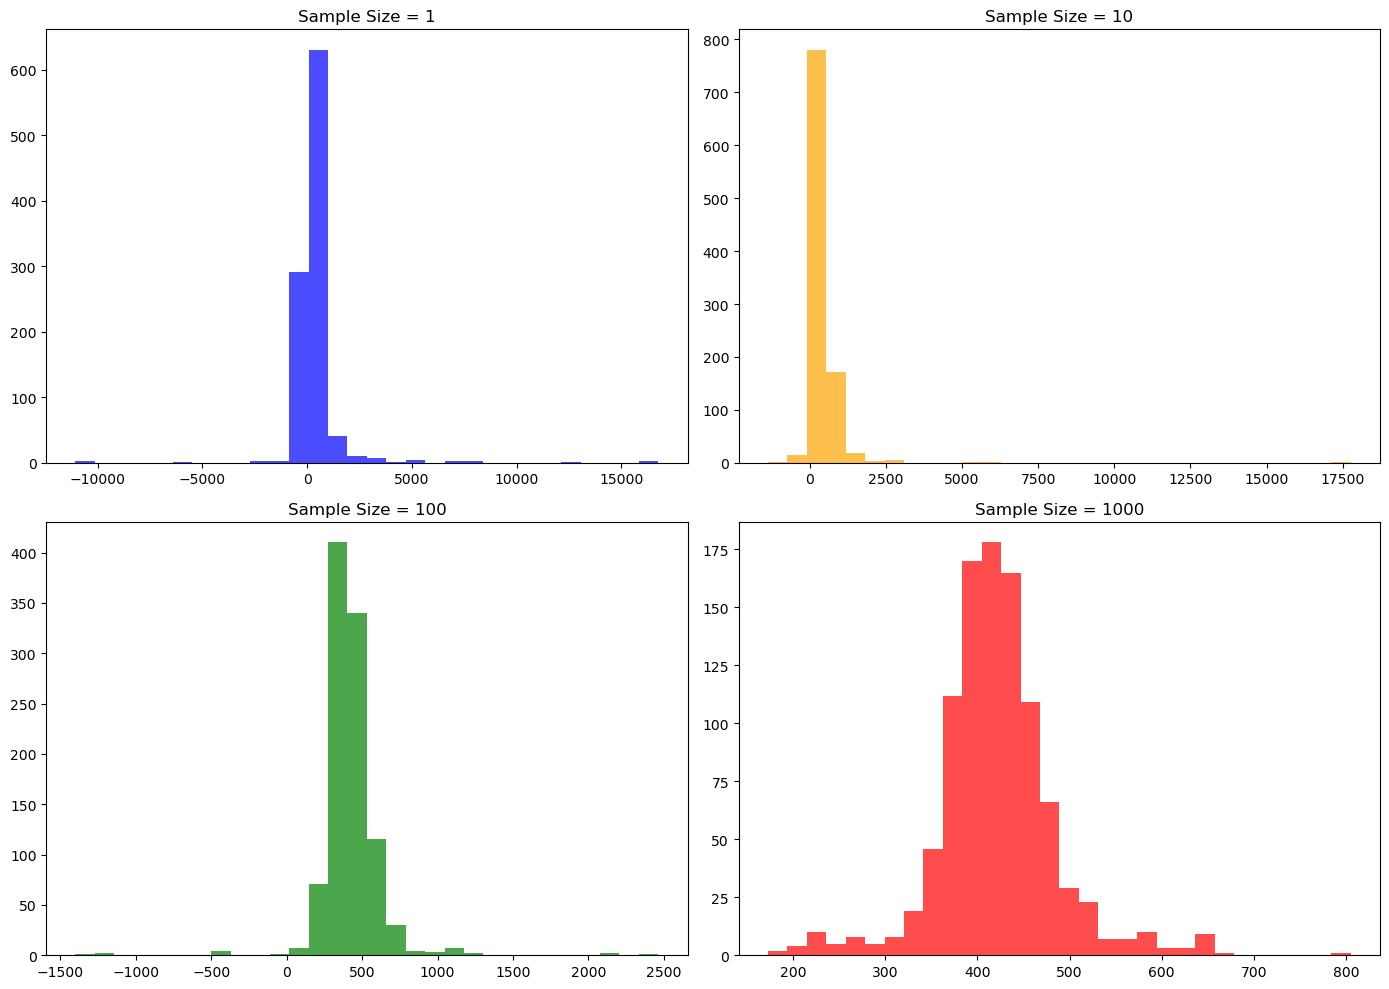

In [9]:
fig , axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(means_1, bins=30, color='blue', alpha=0.7)
axes[0, 0].set_title('Sample Size = 1')

axes[0, 1].hist(means_10, bins=30, color='orange', alpha=0.7)       
axes[0, 1].set_title('Sample Size = 10')

axes[1, 0].hist(means_100, bins=30, color='green', alpha=0.7)
axes[1, 0].set_title('Sample Size = 100')

axes[1, 1].hist(mean_1000, bins=30, color='red', alpha=0.7)
axes[1, 1].set_title('Sample Size = 1000')

plt.tight_layout()
plt.show()